## **1. Importação das bibliotecas**

In [332]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

## **2. Carregamento do Dataset**

In [333]:
sheet_id = "1OmnQ7Yut5YDj-7n4LpLtceW8NGWWp3UW"
gid = "1420226095"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

df = pd.read_csv(url)


# **3. Visão Geral do Dataset**

In [334]:
#dimensões
df.shape

(113634, 13)

In [335]:
#tipo das colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113634 entries, 0 to 113633
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Iso3_code            113634 non-null  str  
 1   Country              113634 non-null  str  
 2   Region               113634 non-null  str  
 3   Subregion            113634 non-null  str  
 4   Indicator            113634 non-null  str  
 5   Dimension            113634 non-null  str  
 6   Category             113634 non-null  str  
 7   Sex                  113634 non-null  str  
 8   Age                  113634 non-null  str  
 9   Year                 113634 non-null  int64
 10  Unit of measurement  113634 non-null  str  
 11  VALUE                113634 non-null  str  
 12  Source               113634 non-null  str  
dtypes: int64(1), str(12)
memory usage: 11.3 MB


In [336]:
#primeiras linhas
df.head()

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,ARM,Armenia,Asia,Western Asia,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,35,CTS
1,CHE,Switzerland,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,28,CTS
2,COL,Colombia,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,15053,CTS
3,CZE,Czechia,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,69,CTS
4,DEU,Germany,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,455,CTS


In [337]:
#estatisticas descritivas
df.describe()

,Year
count,113634.000000
mean,2014.684487
std,6.144394
min,1990.000000
25%,2012.000000
50%,2016.000000
75%,2019.000000
max,2022.000000


# **2. Limpeza e Tratamento**

In [338]:
#valores nulos
df.isnull().sum()

Iso3_code              0
Country                0
Region                 0
Subregion              0
Indicator              0
Dimension              0
Category               0
Sex                    0
Age                    0
Year                   0
Unit of measurement    0
VALUE                  0
Source                 0
dtype: int64

In [339]:
#remover duplicados
df = df.drop_duplicates()

In [340]:
#verificar colunas categóricas
df.select_dtypes(include="object").nunique()

C:\Users\joaom\AppData\Local\Temp\ipykernel_45684\3517050875.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


Iso3_code                231
Country                  231
Region                    23
Subregion                 23
Indicator                  6
Dimension                  6
Category                  24
Sex                        3
Age                       11
Unit of measurement        2
VALUE                  47282
Source                   245
dtype: int64

Tratando a coluna de value (estava como tipo object, por convenção as estatiticas descritivas foi alterado para o tipo float64)

In [341]:
df["VALUE"].head(20)


0        35
1        28
2     15053
3        69
4       455
5        70
6      2764
7       905
8       229
9         1
10      864
11      259
12      809
13      173
14      207
15       16
16      134
17       53
18       16
19     9891
Name: VALUE, dtype: str

In [342]:
df["VALUE"].dtype


<StringDtype(storage='python', na_value=nan)>

In [343]:
df["VALUE"].sample(20)

65186      3,175840899
99955      73,70356426
82316      0,131898541
30486               82
112908     4,085959495
73588     0,9924302384
93256      2,163916689
87912     0,1985904053
57538                0
76562      4,086302713
83201      1,168822535
43401                2
95809       1,81178293
72062                0
78884     0,5733106685
25475               13
92251     0,2256683026
31240                0
58461               33
19354                0
Name: VALUE, dtype: str

In [344]:
df["VALUE"] = (
    df["VALUE"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

In [345]:
df["VALUE"] = pd.to_numeric(
    df["VALUE"],
    errors="coerce"
)

In [346]:
df["VALUE"].dtype

dtype('float64')

In [347]:
df["VALUE"].isnull().sum()


np.int64(0)

# **3. Entendendo os Dados**

In [348]:
#indicadores existentes
df["Indicator"].unique()

<StringArray>
['Persons arrested/suspected for intentional homicide',
                     'Victims of intentional homicide',
   'Victims of intentional homicide – City-level data',
          'Persons convicted for intentional homicide',
         'Death due to intentional homicide in prison',
 'Victims of Intentional Homicide - Regional Estimate']
Length: 6, dtype: str

In [349]:
#quantidade por indicador
df["Indicator"].value_counts()

Indicator
Victims of intentional homicide                        85523
Persons arrested/suspected for intentional homicide    17817
Victims of intentional homicide – City-level data       4030
Victims of Intentional Homicide - Regional Estimate     2772
Persons convicted for intentional homicide              2472
Death due to intentional homicide in prison             1020
Name: count, dtype: int64

In [350]:
#sexos disponiveis
df["Sex"].unique()

<StringArray>
['Male', 'Female', 'Total']
Length: 3, dtype: str

In [351]:
#regiões disponiveis
df["Region"].unique()

<StringArray>
[                           'Asia',                          'Europe',
                        'Americas',                          'Africa',
                         'Oceania',                           'World',
       'Australia and New Zealand',                    'Central Asia',
                    'Eastern Asia',                  'Eastern Europe',
 'Latin America and the Caribbean',                       'Melanesia',
                      'Micronesia',                 'Northern Africa',
                'Northern America',                 'Northern Europe',
                       'Polynesia',              'South-eastern Asia',
                   'Southern Asia',                 'Southern Europe',
              'Sub-Saharan Africa',                    'Western Asia',
                  'Western Europe']
Length: 23, dtype: str

# **4. Filtrando Apenas Homicídios**

In [352]:
homicidios = df[
    (df["Indicator"] == "Victims of intentional homicide") &
    (df["Sex"] == "Total") &
    (df["Unit of measurement"] == "Rate per 100,000 population") &
    (df["Year"] >= 2013) &
    (df["Year"] <= 2022)
].copy()

In [353]:
homicidios.head()

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
63796,ABW,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",5.832037,MD
63797,AIA,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",7.299270,WHO/NSO/SDG/PAHO
63798,ALB,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",4.295095,MD/CTS/GSH 2023 Revision/NSO
63799,AND,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",0.000000,Interpol/CTS
63800,ARE,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",0.651291,CTS


In [354]:
homicidios.shape

(9488, 13)

In [355]:
#estatisticas dos homicicios
homicidios["VALUE"].describe()

count    9488.000000
mean        2.823336
std         7.178446
min         0.000000
25%         0.116347
50%         0.437131
75%         1.855709
max       106.819604
Name: VALUE, dtype: float64

# **Distribuição dos Homicidios**

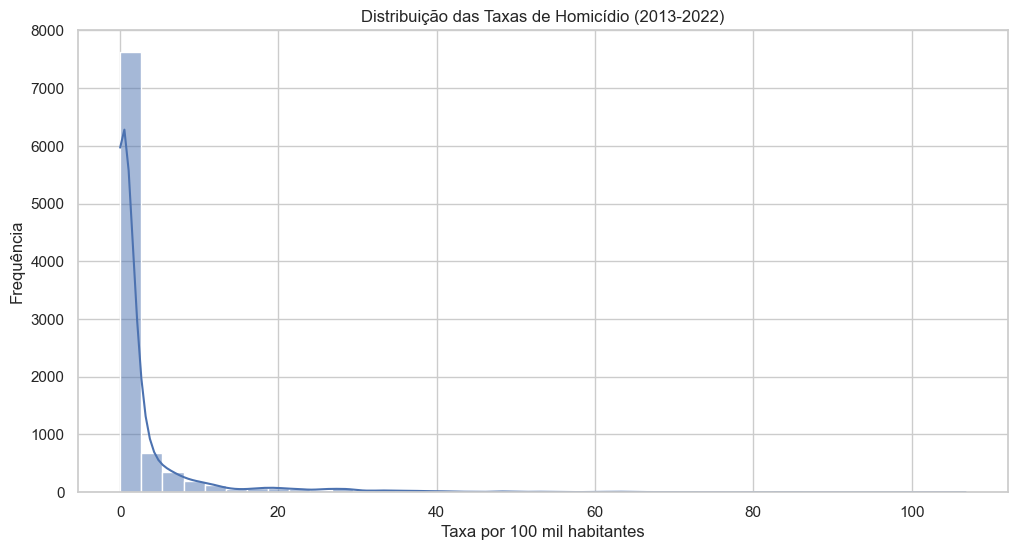

In [356]:
sns.histplot(
    homicidios["VALUE"],
    bins=40,
    kde=True
)

plt.title("Distribuição das Taxas de Homicídio (2013-2022)")
plt.xlabel("Taxa por 100 mil habitantes")
plt.ylabel("Frequência")

plt.show()

In [357]:
regioes = (
    homicidios
    .groupby("Region")["VALUE"]
    .mean()
    .sort_values(ascending=False)
)

regioes

Region
Americas    5.595460
Africa      2.352568
Oceania     1.134564
Asia        1.035240
Europe      0.475159
Name: VALUE, dtype: float64

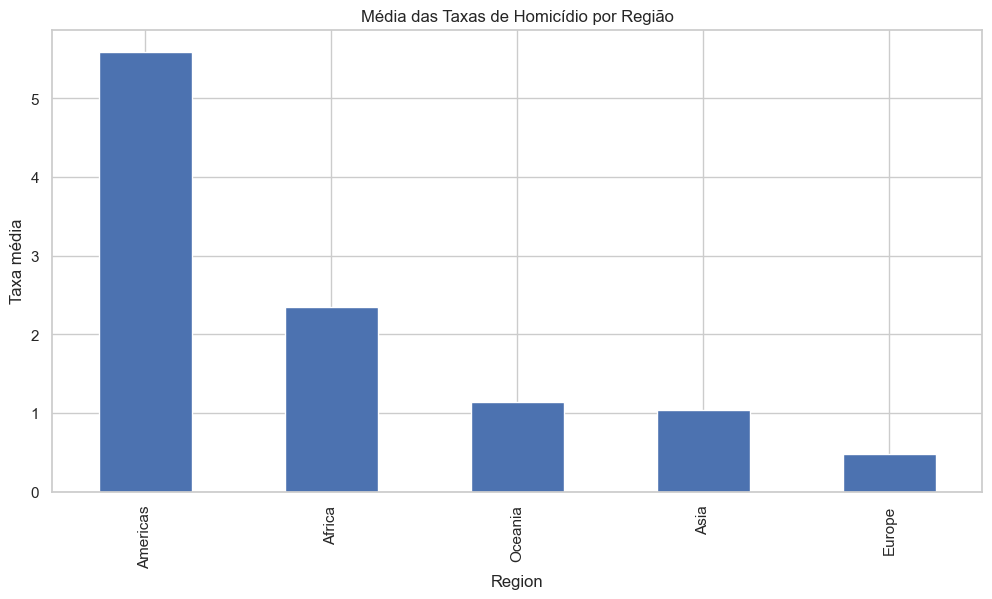

In [358]:
regioes.plot(kind="bar")

plt.title("Média das Taxas de Homicídio por Região")
plt.ylabel("Taxa média")

plt.show()

In [359]:
anos = (
    homicidios
    .groupby("Year")["VALUE"]
    .mean()
)

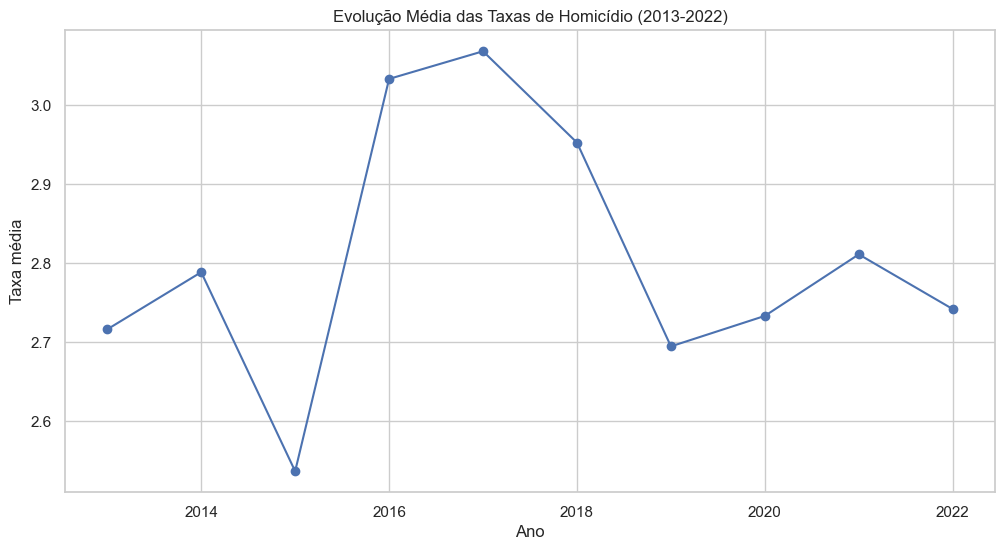

In [360]:
anos.plot(marker="o")

plt.title("Evolução Média das Taxas de Homicídio (2013-2022)")
plt.xlabel("Ano")
plt.ylabel("Taxa média")

plt.show()

In [361]:
top_paises = (
    homicidios
    .groupby("Country")["VALUE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_paises

Country
South Africa                          34.311815
Venezuela (Bolivarian Republic of)    34.309933
Iraq (Central Iraq)                   33.943127
Nigeria                               27.672491
Saint Martin (French Part)            22.748725
Brazil                                18.600385
Anguilla                              17.813439
Jamaica                               13.969865
Honduras                              13.350115
French Guiana                         13.200023
Name: VALUE, dtype: float64

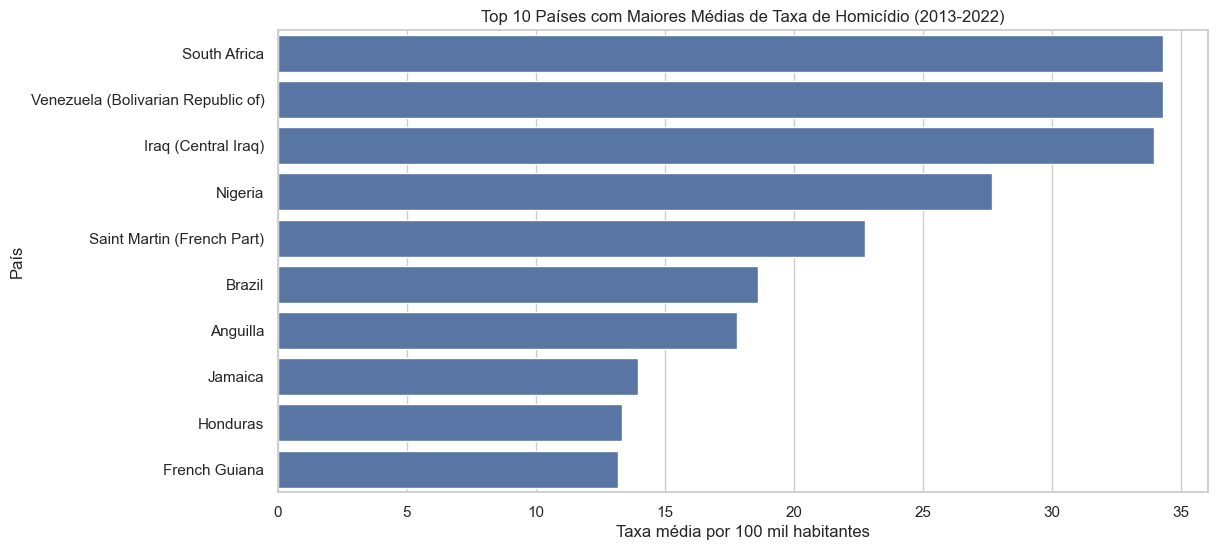

In [362]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_paises.values,
    y=top_paises.index
)

plt.title("Top 10 Países com Maiores Médias de Taxa de Homicídio (2013-2022)")
plt.xlabel("Taxa média por 100 mil habitantes")
plt.ylabel("País")

plt.show()

**Pergunta 1 - Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?**

In [363]:
ultimos_5 = homicidios[
    homicidios["Year"] >= 2018
]

In [364]:
top10 = (
    ultimos_5
    .groupby("Country")["VALUE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10

Country
Iraq (Central Iraq)                   39.910609
South Africa                          35.779754
Venezuela (Bolivarian Republic of)    22.468721
Nigeria                               21.740789
American Samoa                        13.423096
Brazil                                13.292863
French Guiana                         13.200023
Jamaica                               12.795411
Puerto Rico                           12.567775
Haiti                                 12.274497
Name: VALUE, dtype: float64

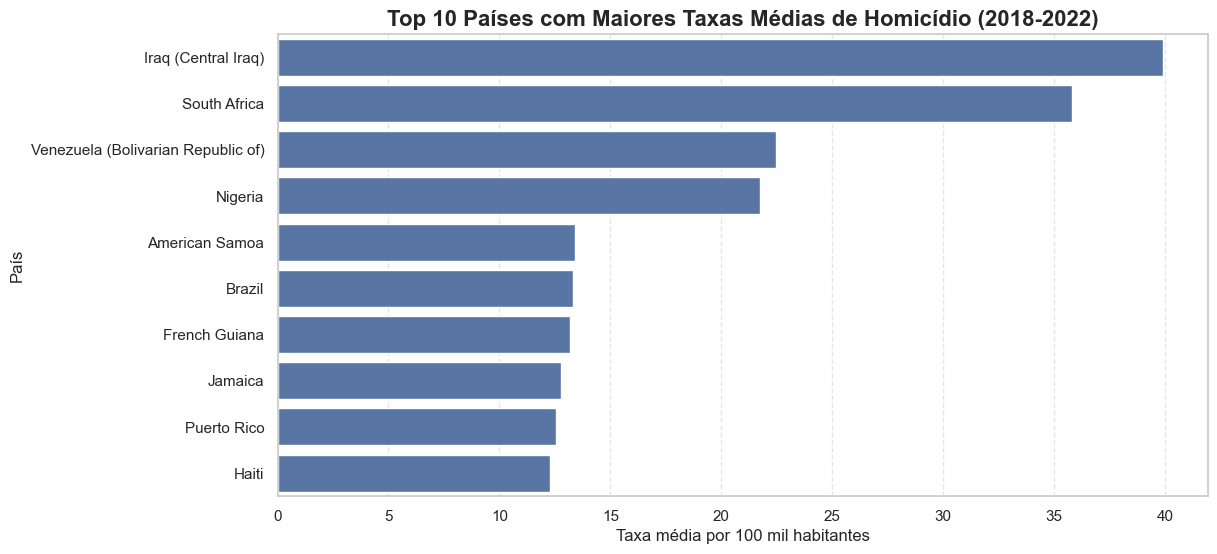

In [365]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title(
    "Top 10 Países com Maiores Taxas Médias de Homicídio (2018-2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Taxa média por 100 mil habitantes", fontsize=12)
plt.ylabel("País", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

**Pergunta 2 - Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022?**

In [366]:
mulheres_2022 = df[
    (df["Indicator"] == "Victims of intentional homicide") &
    (df["Sex"] == "Female") &
    (df["Unit of measurement"] == "Rate per 100,000 population") &
    (df["Year"] == 2022)
]

In [367]:
top_mulheres = (
    mulheres_2022
    .groupby("Country")["VALUE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_mulheres

Country
Saint Lucia                         4.669889
Jamaica                             4.175955
Mexico                              3.892572
Kenya                               3.449769
Haiti                               3.095983
Puerto Rico                         3.084502
Saint Vincent and the Grenadines    3.080055
United States of America            2.755988
Belize                              2.641947
Ecuador                             2.518487
Name: VALUE, dtype: float64

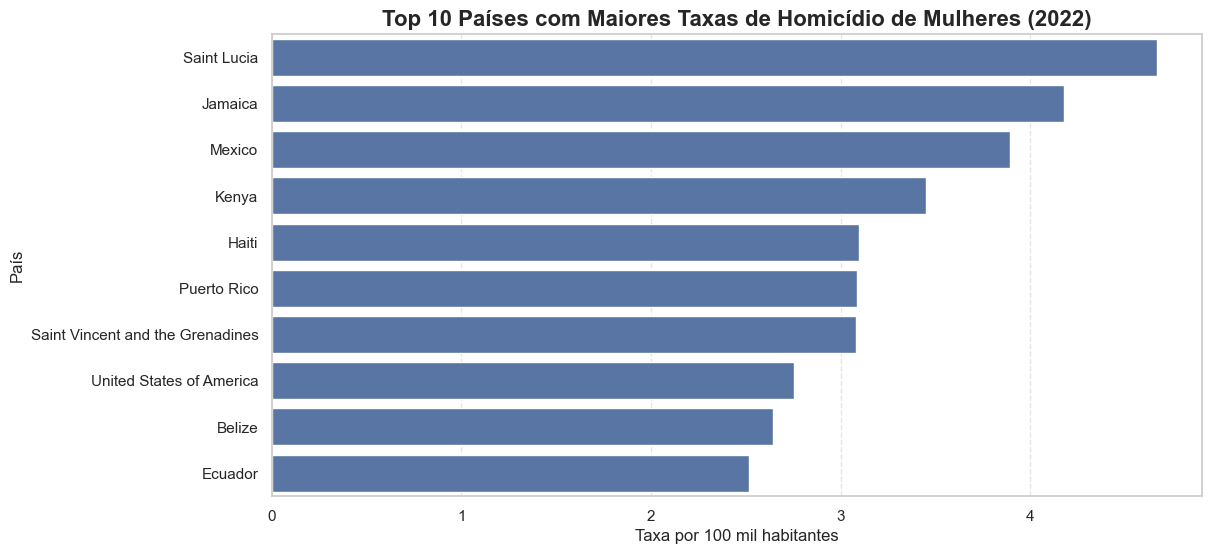

In [368]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_mulheres.values,
    y=top_mulheres.index
)

plt.title(
    "Top 10 Países com Maiores Taxas de Homicídio de Mulheres (2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Taxa por 100 mil habitantes", fontsize=12)
plt.ylabel("País", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

**Pergunta 3 - Quais as regiões com mais homicídios?**

In [369]:
regioes = (
    homicidios
    .groupby("Region")["VALUE"]
    .mean()
    .sort_values(ascending=False)
)

regioes

Region
Americas    5.595460
Africa      2.352568
Oceania     1.134564
Asia        1.035240
Europe      0.475159
Name: VALUE, dtype: float64

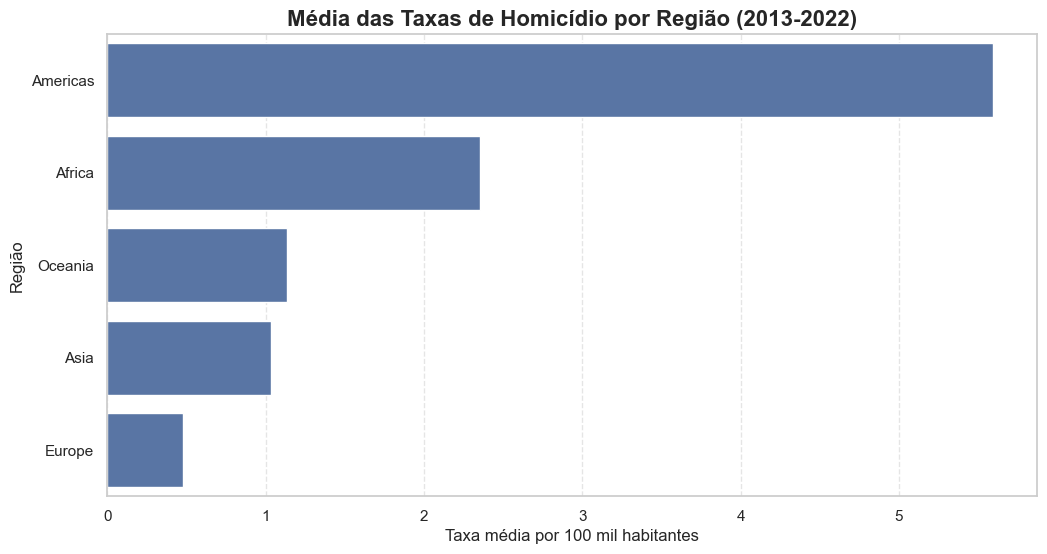

In [370]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=regioes.values,
    y=regioes.index
)

plt.title(
    "Média das Taxas de Homicídio por Região (2013-2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Taxa média por 100 mil habitantes", fontsize=12)
plt.ylabel("Região", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Regressão - Mortes por Ano

In [371]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
homicidios_all_range = df[
    # (df["Indicator"] == "Victims of intentional homicide") &
    (df["Sex"] == "Total") &
    (df["Unit of measurement"] == "Rate per 100,000 population")
].copy()

reg_df = pd.DataFrame(homicidios_all_range.groupby("Year")["VALUE"].sum().reset_index())
reg_df

,Year,VALUE
0,1990,212889.585762
1,1991,213537.906288
2,1992,231808.368846
3,1993,246660.718213
4,1994,281384.070446
5,1995,300293.398210
6,1996,300313.034699
7,1997,296958.940750
8,1998,275343.504981
9,1999,276726.685672


In [ ]:
# Getting best random state and test size with brute force

# best_rs = 0
# best_ts = 0.1
# best_score = 0

# for rs in range(1000):
#   for ts in np.arange(0.1, 0.5, 0.1):
#     X_train, X_test, y_train, y_test = train_test_split(reg_df[["Year"]], reg_df["VALUE"], test_size=ts, random_state=rs)
#     regression = LinearRegression()
#     regression.fit(X_train, y_train)
#     score = regression.score(X_test, y_test)
#     if score > best_score:
#       best_rs = rs
#       best_ts = ts
#       best_score = score

# Best Found
best_rs = 996
best_ts = 0.1
best_score = 0.9894195527507011


In [396]:
print(best_rs)
print(best_ts)
print(best_score)

694
0.1
0.9906159551041774


In [397]:
X_train, X_test, y_train, y_test = train_test_split(reg_df[["Year"]], reg_df["VALUE"], test_size=best_ts, random_state=best_rs)

## Regressor

In [398]:
regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [399]:
regression.score(X_test, y_test)

0.9906159551041774

In [400]:
predict_test = regression.predict(X_test)
predict_test

array([497326.7126123 , 290274.40141404, 587912.09876154, 342037.47921361])

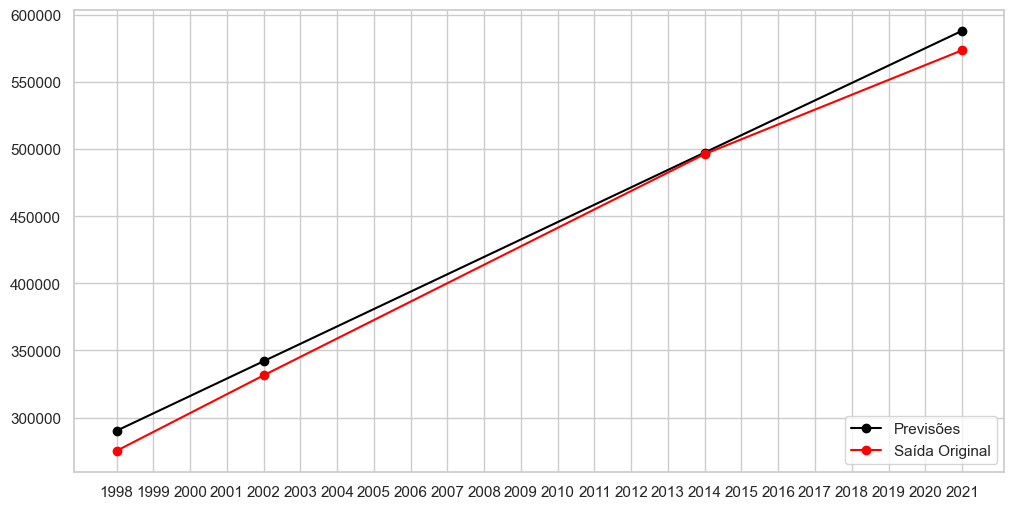

In [401]:
# Organiza os dados para o gráfico
plot_data = []
flatten_years = np.array(X_test).flatten()

for i in range(flatten_years.size):
  plot_data.append({ "Ano": flatten_years[i], "Mortes": np.array(predict_test)[i], "Tipo": "Predição" })
  plot_data.append({ "Ano": flatten_years[i], "Mortes": np.array(y_test)[i], "Tipo": "Real" })

plot_df = pd.DataFrame(plot_data).sort_values("Ano")

plot_anos = np.array(plot_df["Ano"].unique())
plot_predic = np.array(plot_df[plot_df["Tipo"] == "Predição"]["Mortes"])
plot_real = np.array(plot_df[plot_df["Tipo"] == "Real"]["Mortes"])

plt.plot(plot_anos, plot_predic, marker='o', label='Previsões', color='black', linewidth=1.5)
plt.plot(plot_anos, plot_real, marker='o', label='Saída Original', color='red', linewidth=1.5)
plt.xticks(range(plot_anos.min(), plot_anos.max() + 1, 1))
plt.legend(loc="lower right")
plt.show()

In [402]:
anos_predict = pd.DataFrame({ "Year": [2023, 2024, 2025, 2026] })
anos_predict

,Year
0,2023
1,2024
2,2025
3,2026


In [403]:
predict = regression.predict(anos_predict)
predict

array([613793.63766132, 626734.40711121, 639675.17656111, 652615.946011  ])

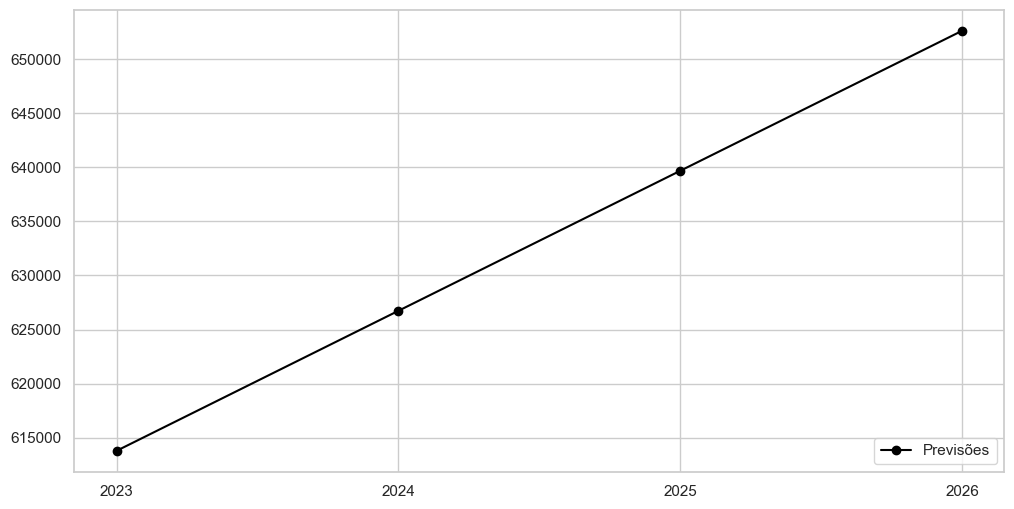

In [404]:
plt.plot(anos_predict, predict, marker="o", label='Previsões', color='black', linewidth=1.5)
plt.xticks(range(2023, 2027, 1))
plt.legend(loc="lower right")
plt.show()